# Visualization Notebook

This notebook combines all visualization codes from two sources:
1. **Sweep results analysis** – bubble chart, heatmaps, parameter counting helpers.
2. **Embedded deployment benchmark** – Figures 4–8 from the paper (latency, energy, Pareto frontier, etc.).

All code is preserved; only comments and text have been translated to American English.

---

In [2]:
# Common imports for both parts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re
import io
import warnings
import os
warnings.filterwarnings("ignore")



from matplotlib.patches import FancyArrowPatch
from matplotlib.ticker import LogLocator, LogFormatter
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

## 1. Sweep Results Analysis (Best Models per Feature)

This section loads the cleaned sweep CSV files, extracts the best model per feature type (MFCC / MFE), and produces:
- A bubble chart (memory footprint vs. test accuracy)
- Rank‑based heatmaps for MFCC and MFE features

**Note:** The CSV files `resultados_sweep_*_clean.csv` are expected to be present in the working directory.

In [7]:
path_csv = os.getcwd() + '\\results\\csv_files\\'
path_figures = os.getcwd() + '\\figures\\'

In [8]:
# ---------------------------------------------------------
# STYLE: ggplot + FONT = 16
# ---------------------------------------------------------
plt.style.use('ggplot')


plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 16
})

sns.set_theme(context="notebook", font_scale=1.6, style=None)

# ---------------------------------------------------------
# DATA LOADING
# ---------------------------------------------------------
files = [
    "resultados_sweep_cnn_clean.csv", 
    "resultados_sweep_fan_clean.csv", 
    "resultados_sweep_mlp_clean.csv", 
    "resultados_sweep_rbfn_clean.csv", 
    "resultados_sweep_kan_clean.csv"
]

best_models = []

for f in files:
    df = pd.read_csv(path_csv + f)
    
    acc_test_col = [c for c in df.columns if 'Accuracy' in c and 'Test' in c][0]
    f1_test_col = [c for c in df.columns if 'F1 Score' in c and 'Test' in c][0]
    prec_test_col = [c for c in df.columns if 'Precision' in c and 'Test' in c][0]
    rec_test_col = [c for c in df.columns if 'Recall' in c and 'Test' in c][0]
    
    acc_train_col = [c for c in df.columns if 'Accuracy' in c and 'Train' in c][0]
    f1_train_col = [c for c in df.columns if 'F1 Score' in c and 'Train' in c][0]
    prec_train_col = [c for c in df.columns if 'Precision' in c and 'Train' in c][0]
    rec_train_col = [c for c in df.columns if 'Recall' in c and 'Train' in c][0]
    
    feat_col = 'Feature type' if 'Feature type' in df.columns else 'feature_type'
    
    for feat in ['MFCC', 'MFE']:
        df_feat = df[df[feat_col] == feat]
        if not df_feat.empty:
            best_idx = df_feat[acc_test_col].idxmax()
            best_row = df_feat.loc[best_idx]
            
            best_models.append({
                'Model': best_row['model_name'],
                'Feature': feat,
                'Accuracy (Train)': best_row[acc_train_col],
                'F1 Score (Train)': best_row[f1_train_col],
                'Precision (Train)': best_row[prec_train_col],
                'Recall (Train)': best_row[rec_train_col],
                'Accuracy (Test)': best_row[acc_test_col],
                'F1 Score (Test)': best_row[f1_test_col],
                'Precision (Test)': best_row[prec_test_col],
                'Recall (Test)': best_row[rec_test_col],
                'Memory (KB)': best_row['C++ File Size (B)'] / 1024,
                'Train Time (s)': best_row['Training Time (s)']
            })

best_df = pd.DataFrame(best_models)
best_df

,Model,Feature,Accuracy (Train),F1 Score (Train),Precision (Train),Recall (Train),Accuracy (Test),F1 Score (Test),Precision (Test),Recall (Test),Memory (KB),Train Time (s)
0,CNN,MFCC,1.000000,1.000000,1.000000,1.000000,0.965116,0.965254,0.965708,0.965116,227.462891,6.294463
1,CNN,MFE,1.000000,1.000000,1.000000,1.000000,0.982558,0.982624,0.983084,0.982558,227.548828,6.466966
2,FAN,MFCC,1.000000,1.000000,1.000000,1.000000,0.988372,0.988338,0.988385,0.988372,34.575195,7.963677
3,FAN,MFE,1.000000,1.000000,1.000000,1.000000,0.986047,0.985994,0.986168,0.986047,33.086914,6.238401
4,MLP,MFCC,0.986903,0.986900,0.986942,0.986903,0.960465,0.960390,0.960653,0.960465,46.091797,0.635928
5,MLP,MFE,0.960419,0.960756,0.961962,0.960419,0.930233,0.930236,0.932187,0.930233,44.970703,0.639931
6,RBFN,MFCC,0.981083,0.981067,0.981168,0.981083,0.973256,0.973212,0.973342,0.973256,281.232422,0.317973
7,RBFN,MFE,0.989232,0.989223,0.989268,0.989232,0.969767,0.969799,0.970292,0.969767,281.430664,0.175597
8,KAN,MFCC,0.889988,0.889414,0.892680,0.889988,0.884884,0.884799,0.891340,0.884884,413.733398,9.405569
9,KAN,MFE,0.890861,0.888983,0.898151,0.890861,0.881395,0.878551,0.897274,0.881395,525.777344,9.360102


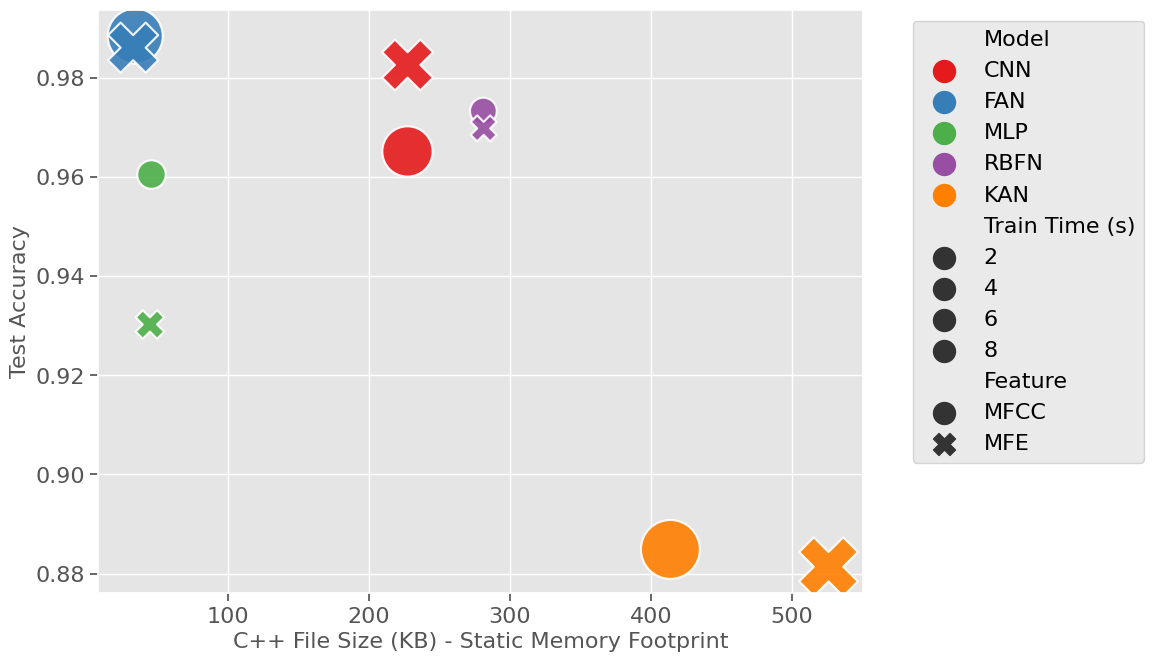

In [9]:
# ---------------------------------------------------------
# 1. BUBBLE CHART (Memory vs. Test Accuracy)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

ax = sns.scatterplot(
    data=best_df, 
    x='Memory (KB)', 
    y='Accuracy (Test)', 
    hue='Model', 
    style='Feature',
    size='Train Time (s)', 
    sizes=(350, 1800),   # larger bubbles
    s=250,               # larger markers
    alpha=0.9, 
    palette='Set1'
)

# Force tick size
ax.tick_params(axis='both', labelsize=16)

plt.xlabel('C++ File Size (KB) - Static Memory Footprint', fontsize=16)
plt.ylabel('Test Accuracy', fontsize=16)

# Legend adjustment
legend = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=16)

for handle in legend.legend_handles:
    try:
        handle.set_sizes([250])  # increase legend marker size
    except:
        pass

plt.tight_layout()
plt.savefig(path_figures + 'bubble_chart_tinyml.pdf', dpi=300)
plt.show()

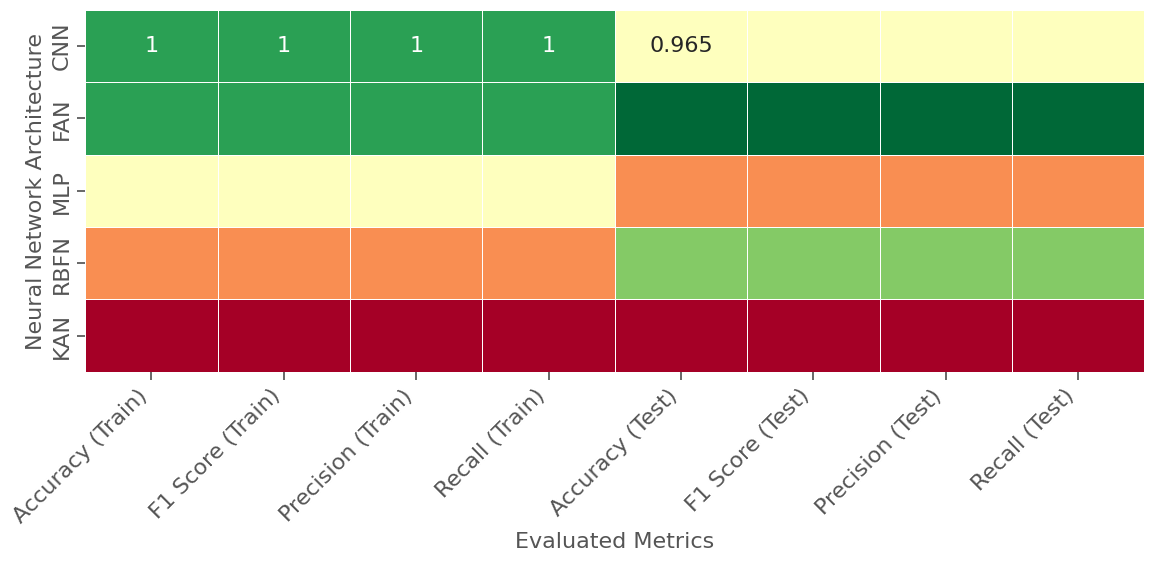

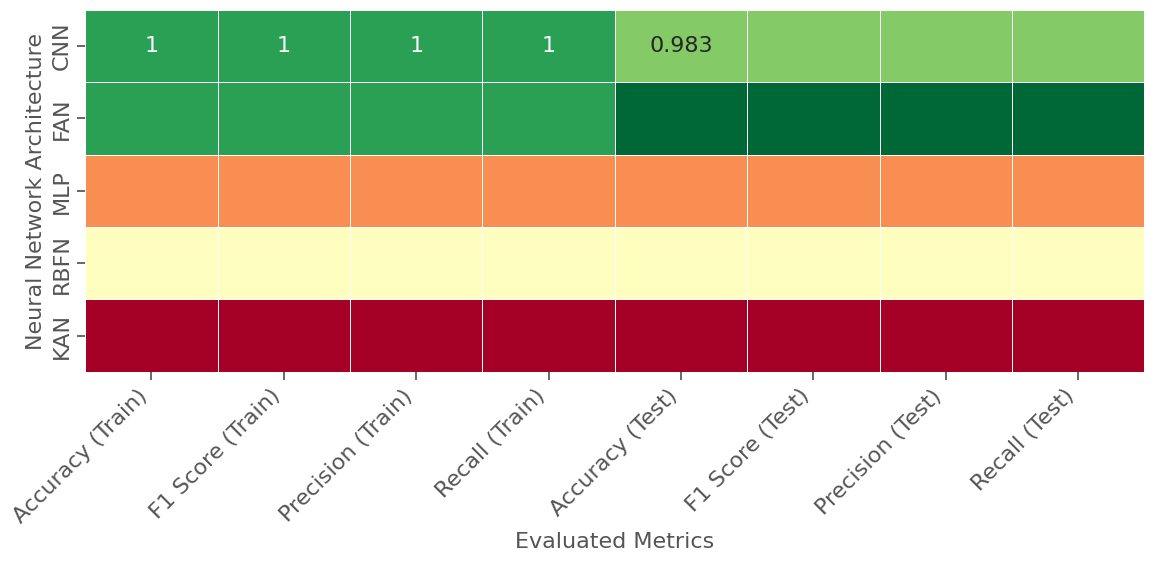

In [10]:
# ---------------------------------------------------------
# 2. HEATMAPS (rank-based, with original values as annotations)
# ---------------------------------------------------------
metrics_cols = [
    'Accuracy (Train)', 'F1 Score (Train)', 'Precision (Train)', 'Recall (Train)',
    'Accuracy (Test)', 'F1 Score (Test)', 'Precision (Test)', 'Recall (Test)'
]

def plot_heatmap(df_subset, filename):
    plt.figure(figsize=(12, 6))
    
    heatmap_data = df_subset.set_index('Model')[metrics_cols]
    
    rank_df = pd.DataFrame(index=heatmap_data.index)
    
    for col in metrics_cols:
        rank_df[col] = heatmap_data[col].rank(ascending=True)

    ax = sns.heatmap(
        rank_df,
        annot=heatmap_data.round(3),
        cmap='RdYlGn',
        fmt='g',
        cbar=False,
        linewidths=.5,
        annot_kws={"size": 16}
    )

    ax.tick_params(axis='both', labelsize=16)

    plt.xlabel('Evaluated Metrics', fontsize=16)
    plt.ylabel('Neural Network Architecture', fontsize=16)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# MFCC
plot_heatmap(
    df_subset=best_df[best_df['Feature'] == 'MFCC'],
    filename=path_figures + 'heatmap_mfcc.pdf'
)

# MFE
plot_heatmap(
    df_subset=best_df[best_df['Feature'] == 'MFE'],
    filename=path_figures + 'heatmap_mfe.pdf'
)

## 3. Embedded Deployment Benchmark (Figures 4–8)

This section generates the main figures for the paper’s embedded benchmark (Section 6.2).  
All data is embedded as a CSV string, so no external files are required.

The following plots are produced:
- **Figure 4:** Inference latency (ms) per architecture and MCU  
- **Figure 5:** Energy per inference (µJ) per architecture and MCU  
- **Figure 6:** Pareto frontier: Test accuracy vs. energy per inference  
- **Figure 7:** Inference time vs. number of parameters (FPU / no‑FPU markers)  
- **Figure 8:** Energy per inference vs. latency (with iso‑energy contours)  

All figures are saved as PDF and PNG in the `outputs/` directory (modify the path if needed).

In [11]:
# ---------------------------------------------------------
# Embedded benchmark data (CSV string)
# ---------------------------------------------------------
RAW_DATA = """model_name,feature_type,Parameters,Sketch,Global,Inference_ms,Current_mA,Voltage_V,Power_mW,MCU,Accuracy
CNN,MFCC,16012,0,0,0,0,5.014,0,ESP8266,0.9651162791
CNN,MFCC,16012,0,0,0,0,5.014,0,STM32F103C,0.9651162791
CNN,MFCC,16012,346344,63028,9.41,61.1,5.014,306.3554,ESP32,0.9651162791
CNN,MFCC,16012,160482,83784,162.07,25.15,5.014,126.1021,Raspberry Pi Pico,0.9651162791
CNN,MFCC,16012,143748,110480,67.41,33.02,5.014,165.56228,Raspberry Pi Pico W,0.9651162791
CNN,MFCC,16012,139392,110908,10.73,14.6,5.014,73.2044,Raspberry Pi Pico 2 W,0.9651162791
CNN,MFCC,16012,116868,50672,10.69,16.6,5.014,83.2324,Raspberry Pi Pico 2,0.9651162791
CNN,MFCC,16012,151496,85408,24.06,18.07,5.014,90.60298,Arduino Nano 33 BLE SENSE,0.9651162791
CNN,MFCC,16012,201504,103944,2.56,111.1,5.014,557.0554,Arduino Portenta H7,0.9651162791
CNN,MFE,16012,0,0,0,0,5.014,0,ESP8266,0.9825581395
CNN,MFE,16012,0,0,0,0,5.014,0,STM32F103C,0.9825581395
CNN,MFE,16012,346344,63028,9.41,61.1,5.014,306.3554,ESP32,0.9825581395
CNN,MFE,16012,160482,83784,162.07,25.15,5.014,126.1021,Raspberry Pi Pico,0.9825581395
CNN,MFE,16012,143748,110480,67.41,33.02,5.014,165.56228,Raspberry Pi Pico W,0.9825581395
CNN,MFE,16012,139392,110908,10.73,14.6,5.014,73.2044,Raspberry Pi Pico 2 W,0.9825581395
CNN,MFE,16012,116868,50672,10.69,16.6,5.014,83.2324,Raspberry Pi Pico 2,0.9825581395
CNN,MFE,16012,151496,85408,24.06,18.07,5.014,90.60298,Arduino Nano 33 BLE SENSE,0.9825581395
CNN,MFE,16012,201504,103944,2.56,111.1,5.014,557.0554,Arduino Portenta H7,0.9825581395
FAN,MFCC,7984,309504,62632,15.4,19.1,3.3,63.03,ESP8266,0.988372093
FAN,MFCC,7984,55432,2912,17.16,9.9,5.014,49.6386,STM32F103C,0.988372093
FAN,MFCC,7984,317376,23556,0.67,53.39,5.014,267.69746,ESP32,0.988372093
FAN,MFCC,7984,132305,44296,20.7,25.13,5.014,126.00182,Raspberry Pi Pico,0.988372093
FAN,MFCC,7984,111444,70992,8.73,31.83,5.014,159.59562,Raspberry Pi Pico W,0.988372093
FAN,MFCC,7984,107320,71428,2.03,14.51,5.014,72.75314,Raspberry Pi Pico 2 W,0.988372093
FAN,MFCC,7984,84652,10712,2.04,16.25,5.014,81.4775,Raspberry Pi Pico 2,0.988372093
FAN,MFCC,7984,123720,46032,1.47,26.85,5.014,134.6259,Arduino Nano 33 BLE SENSE,0.988372093
FAN,MFCC,7984,173112,63984,0.2,111.10,5.014,557.0554,Arduino Portenta H7,0.988372093
FAN,MFE,7792,310096,61384,14.26,21.32,3.3,70.356,ESP8266,0.9860465116
FAN,MFE,7792,55592,2432,15.57,10.03,5.014,50.29042,STM32F103C,0.9860465116
FAN,MFE,7792,317764,23076,0.85,50.68,5.014,254.10952,ESP32,0.9860465116
FAN,MFE,7792,132491,43816,19.6,25.43,5.014,127.50602,Raspberry Pi Pico,0.9860465116
FAN,MFE,7792,110764,70512,8.53,32.3,5.014,161.9522,Raspberry Pi Pico W,0.9860465116
FAN,MFE,7792,106976,70948,1.96,14.8,5.014,74.2072,Raspberry Pi Pico 2 W,0.9860465116
FAN,MFE,7792,84316,10232,1.95,16.1,5.014,80.7254,Raspberry Pi Pico 2,0.9860465116
FAN,MFE,7792,123784,45552,1.38,18,5.014,90.252,Arduino Nano 33 BLE SENSE,0.9860465116
FAN,MFE,7792,173176,63504,0.21,110.7,5.014,555.0498,Arduino Portenta H7,0.9860465116
MLP,MFCC,2140,284192,37304,3.9,16.9,3.3,55.77,ESP8266,0.9604651163
MLP,MFCC,2140,28868,2040,5.11,9.8,5.014,49.1372,STM32F103C,0.9604651163
MLP,MFCC,2140,290696,22548,0.08,50.9,5.014,255.2126,ESP32,0.9604651163
MLP,MFCC,2140,104866,43304,4.24,25.4,5.014,127.3556,Raspberry Pi Pico,0.9604651163
MLP,MFCC,2140,87532,70000,1.76,27.2,5.014,136.3808,Raspberry Pi Pico W,0.9604651163
MLP,MFCC,2140,83280,70428,0.15,14.8,5.014,74.2072,Raspberry Pi Pico 2 W,0.9604651163
MLP,MFCC,2140,60668,9716,0.14,15.3,5.014,76.7142,Raspberry Pi Pico 2,0.9604651163
MLP,MFCC,2140,96864,45032,0.75,20.3,5.014,101.7842,Arduino Nano 33 BLE SENSE,0.9604651163
MLP,MFCC,2140,145904,62992,0.04,109.10,5.014,547.0274,Arduino Portenta H7,0.9604651163
MLP,MFE,2140,284192,37304,3.9,16.9,3.3,55.77,ESP8266,0.9302325581
MLP,MFE,2140,28868,2040,5.11,9.8,5.014,49.1372,STM32F103C,0.9302325581
MLP,MFE,2140,290696,22548,0.08,50.9,5.014,255.2126,ESP32,0.9302325581
MLP,MFE,2140,104866,43304,4.24,25.4,5.014,127.3556,Raspberry Pi Pico,0.9302325581
MLP,MFE,2140,87532,70000,1.76,27.2,5.014,136.3808,Raspberry Pi Pico W,0.9302325581
MLP,MFE,2140,83280,70428,0.15,14.8,5.014,74.2072,Raspberry Pi Pico 2 W,0.9302325581
MLP,MFE,2140,60668,9716,0.14,15.3,5.014,76.7142,Raspberry Pi Pico 2,0.9302325581
MLP,MFE,2140,96864,45032,0.75,20.3,5.014,101.7842,Arduino Nano 33 BLE SENSE,0.9302325581
MLP,MFE,2140,145904,62992,0.04,109.10,5.014,547.0274,Arduino Portenta H7,0.9302325581
KAN,MFCC,19243,0,0,0,0,3.3,0,ESP8266,0.8848837209
KAN,MFCC,19243,0,0,0,0,5.014,0,STM32F103C,0.8848837209
KAN,MFCC,19243,818168,22548,87.19,68.1,5.014,341.4534,ESP32,0.8848837209
KAN,MFCC,19243,584553,43304,341.87,26.6,5.014,133.3724,Raspberry Pi Pico,0.8848837209
KAN,MFCC,19243,563708,70048,83.76,36,5.014,180.504,Raspberry Pi Pico W,0.8848837209
KAN,MFCC,19243,618040,70428,56.08,18.8,5.014,94.2632,Raspberry Pi Pico 2 W,0.8848837209
KAN,MFCC,19243,595380,9712,55.69,21.3,5.014,106.7982,Raspberry Pi Pico 2,0.8848837209
KAN,MFCC,19243,636424,45032,202.18,21.2,5.014,106.2968,Arduino Nano 33 BLE SENSE,0.8848837209
KAN,MFCC,19243,526264,62984,3.4,120.00,5.014,601.68,Arduino Portenta H7,0.8848837209
KAN,MFE,23317,0,0,0,0,3.3,0,ESP8266,0.8813953488
KAN,MFE,23317,0,0,0,0,5.014,0,STM32F103C,0.8813953488
KAN,MFE,23317,1003612,22548,121.89,68.7,5.014,344.4618,ESP32,0.8813953488
KAN,MFE,23317,756965,43304,487.21,26.7,5.014,133.8738,Raspberry Pi Pico,0.8813953488
KAN,MFE,23317,736052,70048,114.99,35.5,5.014,177.997,Raspberry Pi Pico W,0.8813953488
KAN,MFE,23317,796320,70428,72.31,18.7,5.014,93.7618,Raspberry Pi Pico 2 W,0.8813953488
KAN,MFE,23317,773660,9712,71.71,20.3,5.014,101.7842,Raspberry Pi Pico 2,0.8813953488
KAN,MFE,23317,814600,45032,286.72,21.4,5.014,107.2996,Arduino Nano 33 BLE SENSE,0.8813953488
KAN,MFE,23317,646264,62984,4.5,124.20,5.014,622.7388,Arduino Portenta H7,0.8813953488
RBFN,MFCC,26876,0,0,0,0,3.3,0,ESP8266,0.973255814
RBFN,MFCC,26876,0,0,0,0,5.014,0,STM32F103C,0.973255814
RBFN,MFCC,26876,389872,23348,8.75,57.2,5.014,286.8008,ESP32,0.973255814
RBFN,MFCC,26876,204117,44108,99.6,26,5.014,130.364,Raspberry Pi Pico,0.973255814
RBFN,MFCC,26876,186656,70800,39.46,32.6,5.014,163.4564,Raspberry Pi Pico W,0.973255814
RBFN,MFCC,26876,182364,71228,7.36,16.9,5.014,84.7366,Raspberry Pi Pico 2 W,0.973255814
RBFN,MFCC,26876,159696,10512,7.32,17.6,5.014,88.2464,Raspberry Pi Pico 2,0.973255814
RBFN,MFCC,26876,195992,45832,6.22,18.4,5.014,92.2576,Arduino Nano 33 BLE SENSE,0.973255814
RBFN,MFCC,26876,245136,63792,0.79,114.90,5.014,576.1086,Arduino Portenta H7,0.973255814
RBFN,MFE,26876,0,0,0,0,3.3,0,ESP8266,0.9697674419
RBFN,MFE,26876,0,0,0,0,5.014,0,STM32F103C,0.9697674419
RBFN,MFE,26876,389872,23348,8.75,57.2,5.014,286.8008,ESP32,0.9697674419
RBFN,MFE,26876,204117,44108,99.6,26,5.014,130.364,Raspberry Pi Pico,0.9697674419
RBFN,MFE,26876,186656,70800,39.46,32.6,5.014,163.4564,Raspberry Pi Pico W,0.9697674419
RBFN,MFE,26876,182364,71228,7.36,16.9,5.014,84.7366,Raspberry Pi Pico 2 W,0.9697674419
RBFN,MFE,26876,159696,10512,7.32,17.6,5.014,88.2464,Raspberry Pi Pico 2,0.9697674419
RBFN,MFE,26876,195992,45832,6.22,18.4,5.014,92.2576,Arduino Nano 33 BLE SENSE,0.9697674419
RBFN,MFE,26876,245136,63792,0.79,114.90,5.014,576.1086,Arduino Portenta H7,0.9697674419
"""

df_all = pd.read_csv(io.StringIO(RAW_DATA.strip()))
# Keep only entries with valid inference time
df_dep = df_all[df_all["Inference_ms"] > 0].copy()
df_dep["Energy_uJ"] = df_dep["Power_mW"] * df_dep["Inference_ms"]

print(f"Data loaded: {len(df_dep)} deployable configurations.")

Data loaded: 78 deployable configurations.


In [12]:
# ---------------------------------------------------------
# Styling constants for all benchmark figures
# ---------------------------------------------------------
MODEL_COLORS = {
    "FAN":  "#1a6fb5",   # strong blue
    "CNN":  "#e07b00",   # amber
    "MLP":  "#2ca02c",   # green
    "RBFN": "#9467bd",   # purple
    "KAN":  "#d62728",   # red
}
FEAT_MARKERS = {"MFCC": "o", "MFE": "s"}
FEAT_LS      = {"MFCC": "-",  "MFE": "--"}

# FPU presence flag for each MCU
FPU_MAP = {
    "ESP8266":              False,
    "STM32F103C":           False,
    "ESP32":                True,
    "Raspberry Pi Pico":    False,
    "Raspberry Pi Pico W":  False,
    "Raspberry Pi Pico 2":  True,
    "Raspberry Pi Pico 2 W":True,
    "Arduino Nano 33 BLE SENSE": True,
    "Arduino Portenta H7":  True,
}

# Ordered MCU list for bar charts
MCU_ORDER = [
    "ESP8266",
    "STM32F103C",
    "Raspberry Pi Pico",
    "Raspberry Pi Pico W",
    "ESP32",
    "Raspberry Pi Pico 2 W",
    "Raspberry Pi Pico 2",
    "Arduino Nano 33 BLE SENSE",
    "Arduino Portenta H7",
]
MCU_LABELS = {
    "ESP8266":              "ESP8266\n80 MHz\nno FPU",
    "STM32F103C":           "STM32F103C\n72 MHz\nno FPU",
    "Raspberry Pi Pico":    "RPico\n133 MHz\nno FPU",
    "Raspberry Pi Pico W":  "RPico W\n133 MHz\nno FPU",
    "ESP32":                "ESP32\n240 MHz\nFPU",
    "Raspberry Pi Pico 2 W":"RPico 2 W\n150 MHz\nFPU",
    "Raspberry Pi Pico 2":  "RPico 2\n150 MHz\nFPU",
    "Arduino Nano 33 BLE SENSE": "Nano33\n64 MHz\nFPU",
    "Arduino Portenta H7":  "PortentaH7\n480 MHz\nFPU",
}

MODEL_ORDER = ["FAN", "CNN", "MLP", "RBFN", "KAN"]

# Set global matplotlib style for these figures
plt.rcParams.update({
    "font.family": "serif",
    "font.serif":  ["Times New Roman", "DejaVu Serif"],
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":    True,
    "grid.alpha":   0.35,
    "grid.linestyle": "--",
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 150,
})

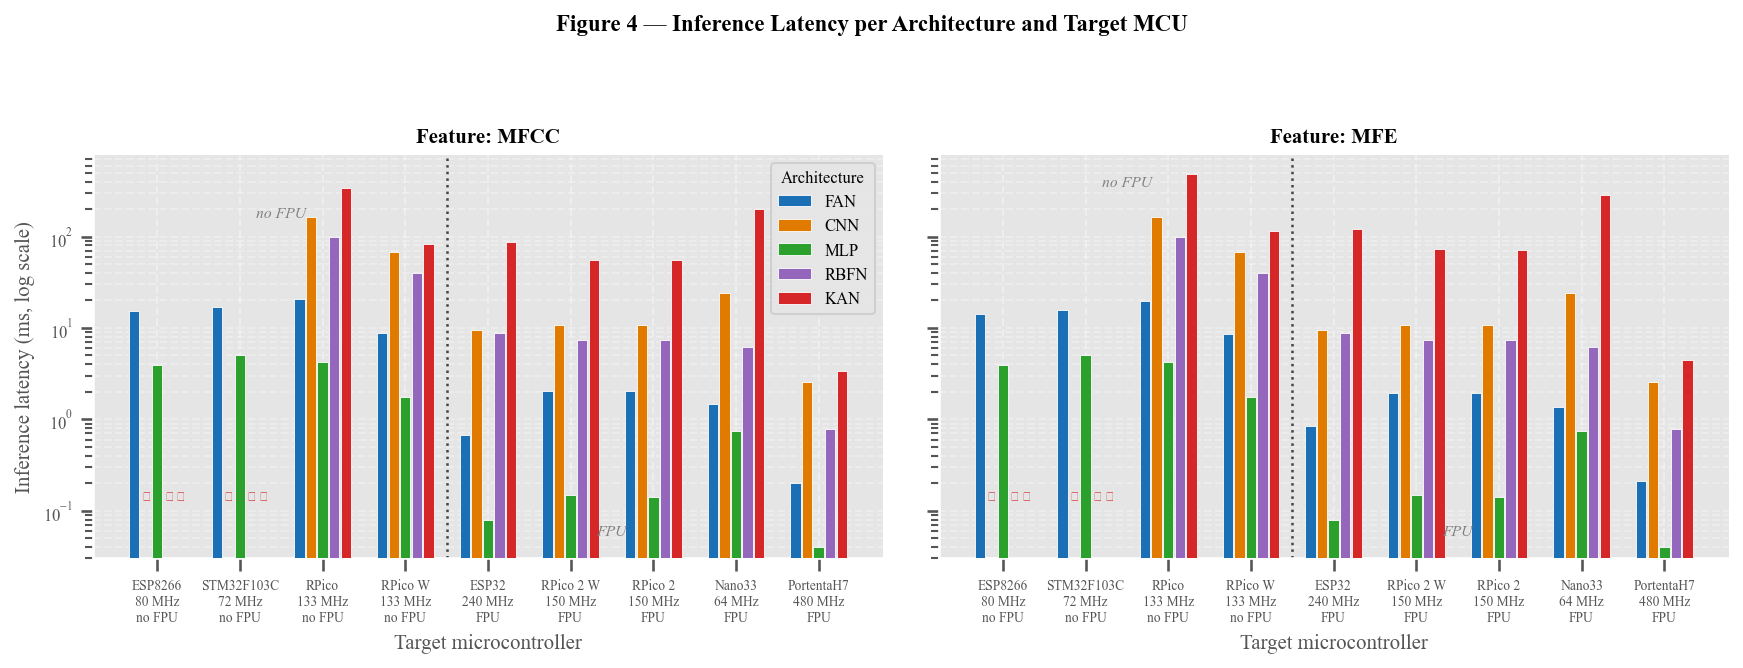

  ✓  Figure 4 saved.


In [13]:
# ---------------------------------------------------------
# FIGURE 4 – Inference Latency (ms) per Model × MCU
# ---------------------------------------------------------
def fig4_latency_per_mcu():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    features = ["MFCC", "MFE"]

    for ax, feat in zip(axes, features):
        subset = df_dep[df_dep["feature_type"] == feat]
        n_mcu   = len(MCU_ORDER)
        n_model = len(MODEL_ORDER)
        width   = 0.14
        x       = np.arange(n_mcu)

        for i, model in enumerate(MODEL_ORDER):
            vals = []
            for mcu in MCU_ORDER:
                row = subset[(subset["model_name"] == model) & (subset["MCU"] == mcu)]
                vals.append(row["Inference_ms"].values[0] if len(row) > 0 else np.nan)

            offset = (i - n_model / 2 + 0.5) * width
            ax.bar(x + offset, vals, width=width * 0.9,
                   color=MODEL_COLORS[model], label=model,
                   zorder=3, edgecolor="white", linewidth=0.4)

        # FPU divider
        ax.axvline(x=3.5, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
        ax.text(1.5, ax.get_ylim()[1] * 0.5 if ax.get_ylim()[1] > 0 else 600,
                "no FPU", ha="center", va="center", fontsize=7.5,
                color="gray", style="italic")
        ax.text(5.5, 0.05, "FPU", ha="center", va="bottom",
                fontsize=7.5, color="gray", style="italic")

        ax.set_yscale("log")
        ax.set_xticks(x)
        ax.set_xticklabels([MCU_LABELS[m] for m in MCU_ORDER], fontsize=6.5)
        ax.set_title(f"Feature: {feat}", fontsize=10, fontweight="bold")
        ax.set_ylabel("Inference latency (ms, log scale)" if feat == "MFCC" else "")
        ax.set_xlabel("Target microcontroller")
        ax.yaxis.grid(True, which="both", alpha=0.3)

        # Annotate non-deployable with ✕
        for i, mcu in enumerate(MCU_ORDER):
            for j, model in enumerate(MODEL_ORDER):
                row = subset[(subset["model_name"] == model) & (subset["MCU"] == mcu)]
                if len(row) == 0 or row["Inference_ms"].values[0] == 0:
                    if mcu in ["ESP8266", "STM32F103C"] and model not in ["FAN", "MLP"]:
                        offset = (j - n_model / 2 + 0.5) * width
                        ax.text(i + offset, 0.12, "✕", ha="center", va="bottom",
                                fontsize=6, color="#cc0000", fontweight="bold")

    axes[0].legend(loc="upper right", ncol=1, framealpha=0.85,
                   title="Architecture", title_fontsize=8)

    # Restore ylim after annotations
    for ax in axes:
        ax.set_ylim(bottom=0.03)

    fig.suptitle("Figure 4 — Inference Latency per Architecture and Target MCU",
                 fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    # Save figures (update output path as needed)
    fig.savefig(path_figures + "fig4_latency_per_mcu.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(path_figures + "fig4_latency_per_mcu.png", bbox_inches="tight", dpi=200)
    plt.show()
    print("  ✓  Figure 4 saved.")

fig4_latency_per_mcu()

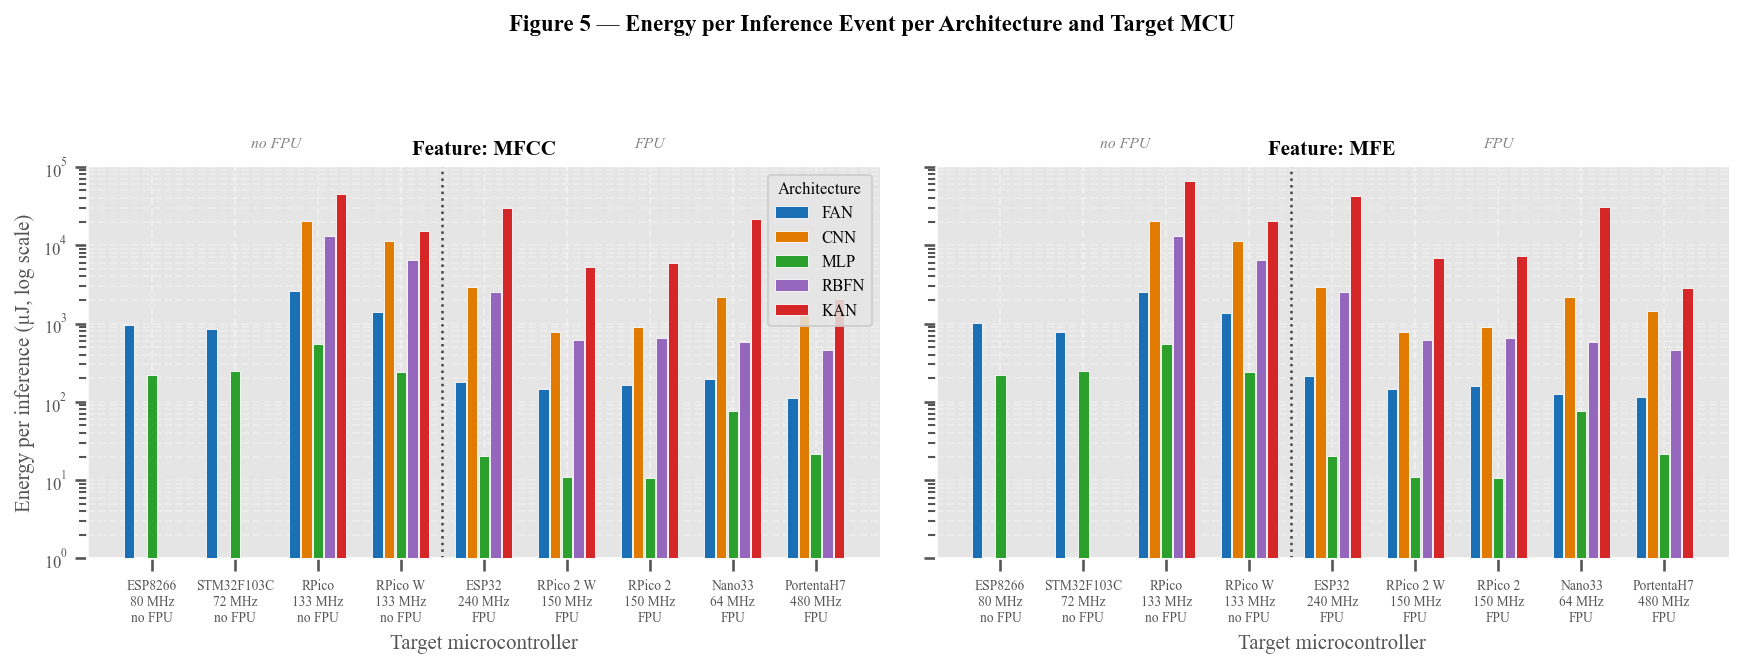

  ✓  Figure 5 saved.


In [15]:
# ---------------------------------------------------------
# FIGURE 5 – Energy per Inference (µJ) per Model × MCU
# ---------------------------------------------------------
def fig5_energy_per_mcu():
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    features = ["MFCC", "MFE"]

    for ax, feat in zip(axes, features):
        subset = df_dep[df_dep["feature_type"] == feat]
        n_mcu   = len(MCU_ORDER)
        n_model = len(MODEL_ORDER)
        width   = 0.14
        x       = np.arange(n_mcu)

        for i, model in enumerate(MODEL_ORDER):
            vals = []
            for mcu in MCU_ORDER:
                row = subset[(subset["model_name"] == model) & (subset["MCU"] == mcu)]
                vals.append(row["Energy_uJ"].values[0] if len(row) > 0 else np.nan)

            offset = (i - n_model / 2 + 0.5) * width
            ax.bar(x + offset, vals, width=width * 0.9,
                   color=MODEL_COLORS[model], label=model,
                   zorder=3, edgecolor="white", linewidth=0.4)

        ax.axvline(x=3.5, color="black", linewidth=1.2, linestyle=":", alpha=0.7)
        ax.text(1.5, 200000, "no FPU", ha="center", va="center",
                fontsize=7.5, color="gray", style="italic")
        ax.text(6.0, 200000, "FPU", ha="center", va="center",
                fontsize=7.5, color="gray", style="italic")

        ax.set_yscale("log")
        ax.set_xticks(x)
        ax.set_xticklabels([MCU_LABELS[m] for m in MCU_ORDER], fontsize=6.5)
        ax.set_title(f"Feature: {feat}", fontsize=10, fontweight="bold")
        ax.set_ylabel("Energy per inference (µJ, log scale)" if feat == "MFCC" else "")
        ax.set_xlabel("Target microcontroller")
        ax.yaxis.grid(True, which="both", alpha=0.3)

    axes[0].legend(loc="upper right", ncol=1, framealpha=0.85,
                   title="Architecture", title_fontsize=8)
    axes[0].set_ylim(bottom=1)

    fig.suptitle("Figure 5 — Energy per Inference Event per Architecture and Target MCU",
                 fontsize=11, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(path_figures + "fig5_energy_per_mcu.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(path_figures + "fig5_energy_per_mcu.png", bbox_inches="tight", dpi=200)
    plt.show()
    print("  ✓  Figure 5 saved.")

fig5_energy_per_mcu()

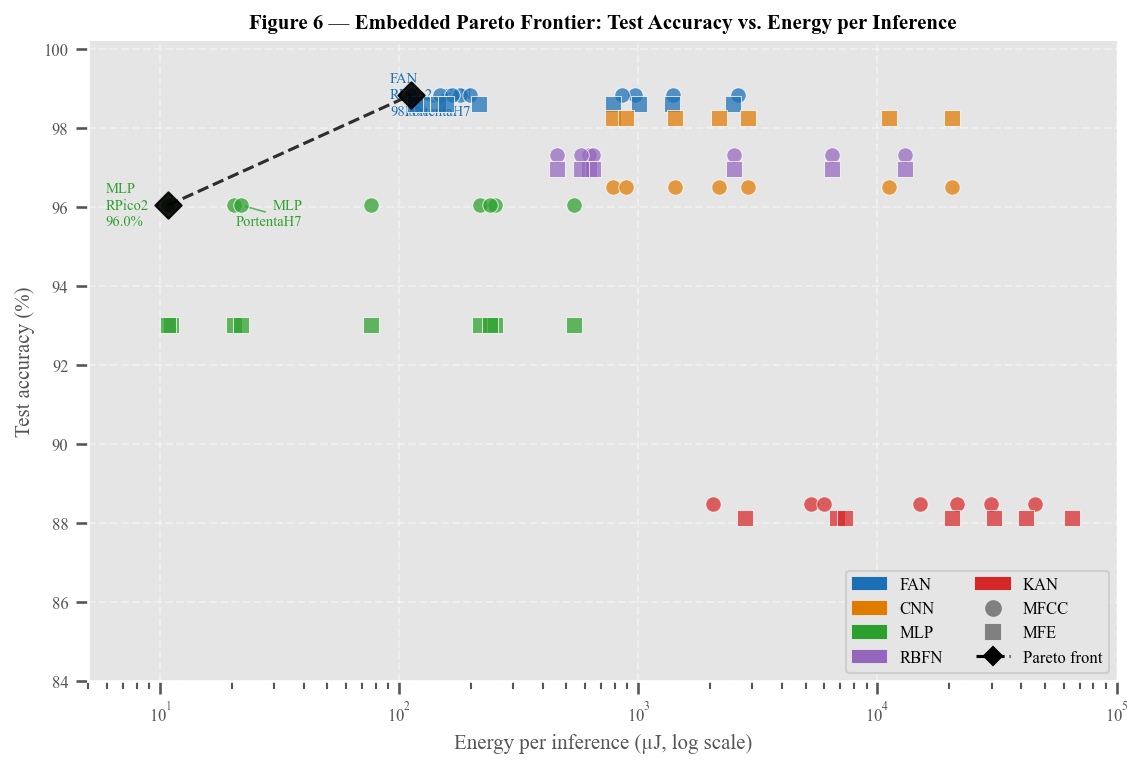

  ✓  Figure 6 saved.


In [18]:
# ---------------------------------------------------------
# FIGURE 6 – Accuracy vs Energy per Inference (Pareto frontier)
# ---------------------------------------------------------
def pareto_front(x_vals, y_vals):
    """Return boolean mask of non-dominated points (min x, max y)."""
    n   = len(x_vals)
    dom = np.zeros(n, dtype=bool)
    for i in range(n):
        dominated = False
        for j in range(n):
            if j == i: continue
            if x_vals[j] <= x_vals[i] and y_vals[j] >= y_vals[i]:
                if x_vals[j] < x_vals[i] or y_vals[j] > y_vals[i]:
                    dominated = True
                    break
        dom[i] = not dominated
    return dom

def fig6_pareto_acc_energy():
    fig, ax = plt.subplots(figsize=(8, 5.5))

    # Use best feature per model for each MCU (MFCC generally gives highest accuracy)
    for model in MODEL_ORDER:
        for feat in ["MFCC", "MFE"]:
            sub = df_dep[(df_dep["model_name"] == model) &
                         (df_dep["feature_type"] == feat)]
            if sub.empty: continue
            ax.scatter(sub["Energy_uJ"], sub["Accuracy"] * 100,
                       color=MODEL_COLORS[model],
                       marker=FEAT_MARKERS[feat],
                       s=55, alpha=0.72, zorder=4,
                       edgecolors="white", linewidths=0.5)

    # Compute and draw Pareto frontier using best-of-feature per MCU
    best = df_dep.loc[df_dep.groupby(["model_name", "MCU"])["Accuracy"].idxmax()]
    xe = best["Energy_uJ"].values
    ya = best["Accuracy"].values * 100
    mask = pareto_front(xe, ya)
    px = xe[mask]
    py = ya[mask]
    sort_idx = np.argsort(px)
    px, py = px[sort_idx], py[sort_idx]
    ax.plot(px, py, color="black", linewidth=1.5,
            linestyle="--", zorder=5, label="Pareto frontier", alpha=0.8)
    ax.scatter(px, py, color="black", s=80, zorder=6,
               marker="D", alpha=0.9, edgecolors="black")

    # Annotate key Pareto points
    annotations = {
        ("FAN",  "Raspberry Pi Pico 2"):    ("FAN\nRPico2\n98.8%",   "left"),
        ("FAN",  "Arduino Portenta H7"):     ("FAN\nPortentaH7",       "right"),
        ("MLP",  "Raspberry Pi Pico 2"):     ("MLP\nRPico2\n96.0%",   "left"),
        ("MLP",  "Arduino Portenta H7"):     ("MLP\nPortentaH7",       "right"),
    }
    for (m, mcu), (label, ha) in annotations.items():
        row = df_dep[(df_dep["model_name"] == m) & (df_dep["MCU"] == mcu) &
                     (df_dep["feature_type"] == "MFCC")]
        if row.empty: continue
        xe_ = row["Energy_uJ"].values[0]
        ya_ = row["Accuracy"].values[0] * 100
        ax.annotate(label, xy=(xe_, ya_),
                    xytext=(xe_ * (1.8 if ha == "right" else 0.55), ya_ - 0.5),
                    fontsize=7, ha=ha, color=MODEL_COLORS[m],
                    arrowprops=dict(arrowstyle="-", color=MODEL_COLORS[m],
                                   lw=0.8, alpha=0.7))

    ax.set_xscale("log")
    ax.set_xlabel("Energy per inference (µJ, log scale)", fontsize=10)
    ax.set_ylabel("Test accuracy (%)", fontsize=10)
    ax.set_xlim(left=5)
    ax.set_ylim([84, 100.2])

    # Legend
    model_patches = [mpatches.Patch(color=MODEL_COLORS[m], label=m)
                     for m in MODEL_ORDER]
    feat_handles  = [mlines.Line2D([], [], color="gray", marker=FEAT_MARKERS[f],
                                   linestyle="None", markersize=7, label=f)
                     for f in ["MFCC", "MFE"]]
    pareto_handle = mlines.Line2D([], [], color="black", linestyle="--",
                                  marker="D", markersize=6, label="Pareto front")
    ax.legend(handles=model_patches + feat_handles + [pareto_handle],
              loc="lower right", ncol=2, fontsize=8, framealpha=0.9)

    ax.set_title("Figure 6 — Embedded Pareto Frontier: Test Accuracy vs. Energy per Inference",
                 fontsize=10, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path_figures + "fig6_pareto_acc_energy.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(path_figures + "fig6_pareto_acc_energy.png", bbox_inches="tight", dpi=200)
    plt.show()
    print("  ✓  Figure 6 saved.")

fig6_pareto_acc_energy()

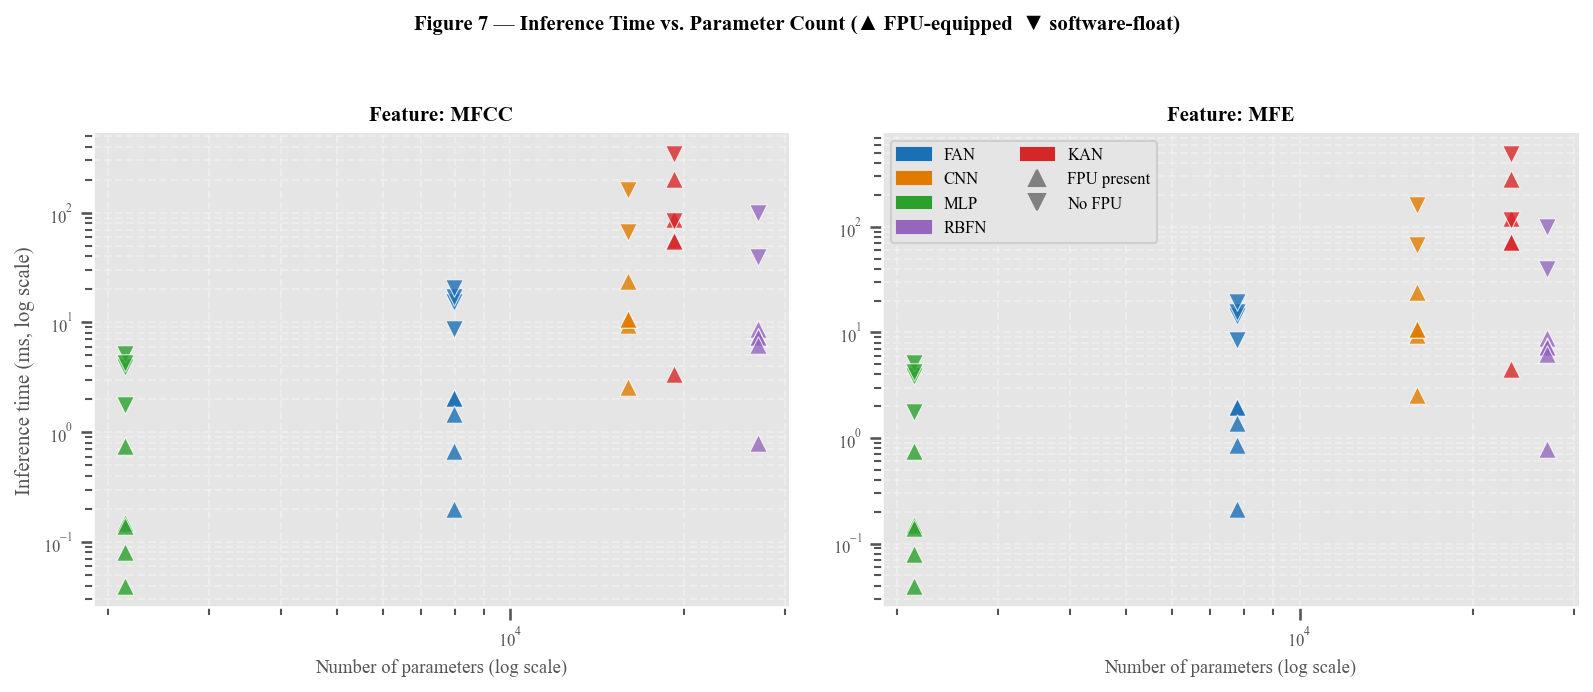

  ✓  Figure 7 saved.


In [17]:
# ---------------------------------------------------------
# FIGURE 7 – Inference Time vs Number of Parameters (FPU / no-FPU markers)
# ---------------------------------------------------------
def fig7_latency_vs_params():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

    for ax, feat in zip(axes, ["MFCC", "MFE"]):
        sub = df_dep[df_dep["feature_type"] == feat].copy()
        sub["has_fpu"] = sub["MCU"].map(FPU_MAP)

        for model in MODEL_ORDER:
            ms = sub[sub["model_name"] == model]
            for _, row in ms.iterrows():
                marker = "^" if row["has_fpu"] else "v"
                ax.scatter(row["Parameters"], row["Inference_ms"],
                           color=MODEL_COLORS[model],
                           marker=marker, s=70, alpha=0.8,
                           edgecolors="white", linewidths=0.5, zorder=4)

        # Dummy legend entries for models
        for model in MODEL_ORDER:
            ms = sub[sub["model_name"] == model]
            if len(ms) < 2: continue
            ax.scatter([], [], color=MODEL_COLORS[model],
                       label=model, s=55, zorder=5)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Number of parameters (log scale)", fontsize=9)
        ax.set_ylabel("Inference time (ms, log scale)" if feat == "MFCC" else "")
        ax.set_title(f"Feature: {feat}", fontsize=10, fontweight="bold")
        ax.grid(True, which="both", alpha=0.3)

    # Shared legend
    model_patches = [mpatches.Patch(color=MODEL_COLORS[m], label=m)
                     for m in MODEL_ORDER]
    fpu_handles = [
        mlines.Line2D([], [], color="gray", marker="^", linestyle="None",
                      markersize=8, label="FPU present"),
        mlines.Line2D([], [], color="gray", marker="v", linestyle="None",
                      markersize=8, label="No FPU"),
    ]
    axes[1].legend(handles=model_patches + fpu_handles,
                   loc="upper left", ncol=2, fontsize=8, framealpha=0.9)

    fig.suptitle("Figure 7 — Inference Time vs. Parameter Count "
                 "(▲ FPU-equipped  ▼ software-float)",
                 fontsize=10, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path_figures + "fig7_latency_vs_params.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(path_figures + "fig7_latency_vs_params.png", bbox_inches="tight", dpi=200)
    plt.show()
    print("  ✓  Figure 7 saved.")

fig7_latency_vs_params()

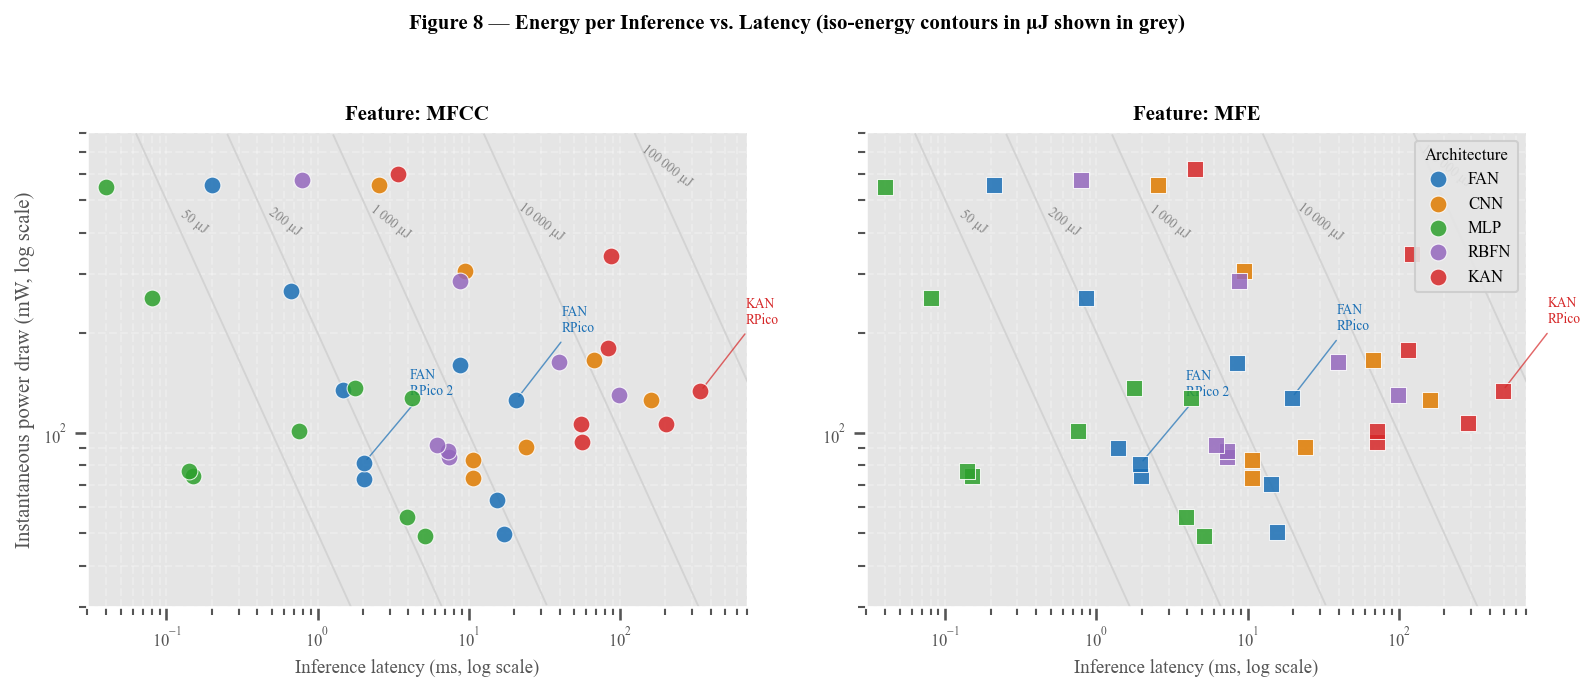

  ✓  Figure 8 saved.


In [16]:
# ---------------------------------------------------------
# FIGURE 8 – Energy per Inference vs. Latency (iso-energy contours)
# ---------------------------------------------------------
def _iso_label_pos(E_uJ, T_min=0.03, T_max=700, P_min=30, P_max=800):
    """
    Return (T_label, P_label) for an iso-energy contour E = P * T.
    Places the label at a fixed fractional position along the visible segment
    of the contour (inside xlim × ylim).
    """
    T_lo = max(T_min, E_uJ / P_max)
    T_hi = min(T_max, E_uJ / P_min)
    if T_lo >= T_hi:
        return None
    # Place label at 25% of the log-range (upper-left portion)
    T_label = np.exp(np.log(T_lo) + 0.25 * (np.log(T_hi) - np.log(T_lo)))
    P_label = E_uJ / T_label
    return T_label, P_label

def fig8_energy_vs_latency():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

    X_LIM = (0.03, 700)
    Y_LIM = (30,   800)

    iso_vals = [50, 200, 1000, 10000, 100000]
    t_range  = np.logspace(np.log10(X_LIM[0]), np.log10(X_LIM[1]), 500)

    for ax, feat in zip(axes, ["MFCC", "MFE"]):
        sub = df_dep[df_dep["feature_type"] == feat].copy()

        # Draw iso-energy contours
        for E in iso_vals:
            P_line = E / t_range
            mask   = (P_line >= Y_LIM[0]) & (P_line <= Y_LIM[1])
            if mask.any():
                ax.plot(t_range[mask], P_line[mask], color="lightgray",
                        linewidth=0.9, linestyle="-", zorder=1, clip_on=True)

            pos = _iso_label_pos(E, T_min=X_LIM[0], T_max=X_LIM[1],
                                    P_min=Y_LIM[0], P_max=Y_LIM[1])
            if pos is not None:
                T_lbl, P_lbl = pos
                ax.text(T_lbl, P_lbl * 1.18,
                        f"{E:,} µJ".replace(",", "\u202f"),
                        fontsize=6.5, color="#888888",
                        ha="center", va="bottom",
                        rotation=-38, rotation_mode="anchor",
                        clip_on=True, zorder=2)

        for model in MODEL_ORDER:
            ms = sub[sub["model_name"] == model]
            ax.scatter(ms["Inference_ms"], ms["Power_mW"],
                       color=MODEL_COLORS[model],
                       marker=FEAT_MARKERS[feat],
                       s=65, alpha=0.85, zorder=4,
                       edgecolors="white", linewidths=0.5, label=model)

        # Annotate FAN and MLP on key MCUs
        for model, mcu_label in [("FAN", "Raspberry Pi Pico 2"),
                                  ("FAN", "Raspberry Pi Pico"),
                                  ("KAN", "Raspberry Pi Pico")]:
            row = sub[(sub["model_name"] == model) & (sub["MCU"] == mcu_label)]
            if row.empty: continue
            r = row.iloc[0]
            ax.annotate(f"{model}\n{mcu_label.replace('Raspberry Pi ', 'R')}",
                        xy=(r["Inference_ms"], r["Power_mW"]),
                        xytext=(r["Inference_ms"] * 2.0, r["Power_mW"] * 1.6),
                        fontsize=6.5, color=MODEL_COLORS[model],
                        arrowprops=dict(arrowstyle="-", color=MODEL_COLORS[model],
                                        lw=0.7, alpha=0.7))

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Inference latency (ms, log scale)", fontsize=9)
        ax.set_ylabel("Instantaneous power draw (mW, log scale)"
                      if feat == "MFCC" else "")
        ax.set_title(f"Feature: {feat}", fontsize=10, fontweight="bold")
        ax.set_xlim(X_LIM)
        ax.set_ylim(Y_LIM)
        ax.grid(True, which="both", alpha=0.25)

    # Deduplicated legend
    handles, labels = axes[0].get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = h
    axes[1].legend(seen.values(), seen.keys(),
                   loc="upper right", ncol=1, fontsize=8, framealpha=0.9,
                   title="Architecture", title_fontsize=8)

    fig.suptitle("Figure 8 — Energy per Inference vs. Latency "
                 "(iso-energy contours in µJ shown in grey)",
                 fontsize=10, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path_figures + "fig8_energy_vs_latency.pdf", bbox_inches="tight", format="pdf")
    fig.savefig(path_figures + "fig8_energy_vs_latency.png", bbox_inches="tight", dpi=200)
    plt.show()
    print("  ✓  Figure 8 saved.")

fig8_energy_vs_latency()